In [28]:
import os
os.listdir()

['abnorm (1).jpeg',
 'abnorm (2).jpeg',
 'abnorm (3).jpeg',
 'abnorm (4).jpeg',
 'best_model.pth',
 'chest_pneumonia_model.pth',
 'chest_xray',
 'norm (4).jpeg',
 'norm (5).jpeg',
 'norm (6).jpeg',
 'norm (7).jpeg',
 'pneumoniadetectionimagepytorch.ipynb',
 'predictionfile.ipynb']

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms 
from PIL import Image
import matplotlib.pyplot as plt
import os


In [56]:
# CONFIGURATION

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ["NORMAL", "PNEUMONIA"]  # must match training order 


# DEFINING SAME TRANSFORMS AS TRAINING

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])


In [57]:
# REBUILD ARCHITECTURE + LOAD SAVED WEIGHTS


class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding="same"),
            nn.BatchNorm2d(32),
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding="same"),
            nn.BatchNorm2d(64), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding="same"),
            nn.BatchNorm2d(128), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding="same"),
            nn.BatchNorm2d(256), 
            nn.ReLU(), 
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(256 * 8 * 8, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, num_classes)
        ) 
        
    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = CNN(num_classes=2)
model.load_state_dict(torch.load("chest_pneumonia_model.pth", map_location=device))
model.to(device) 
model.eval() 


CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()


In [58]:
# PREDICT ON A SINGLE NEW IMAGE

def predict_image(img_name):
    
    img = Image.open(img_name).convert("RGB")  # convert handles grayscale X-rays safely
    img_tensor = transform(img).unsqueeze(0).to(device)  #After transform(img), our images tensor has shape [3, 128, 128] (channels, height, width). But the model expects a batch — shape [batch_size, 3, 128, 128]. .unsqueeze(0) adds that missing batch dimension, turning [3, 128, 128] → [1, 3, 128, 128], meaning "1 image in this batch."

    # run through model
    with torch.no_grad():
        output = model(img_tensor) #Passes the image through all the conv and fc layers — returns raw scores (logits) like tensor([[-1.2, 3.7]]), one score per class, not yet probabilities.
        probs = torch.softmax(output, dim=1) #Converts those raw scores into real probabilities that sum to 1 — e.g. tensor([[0.02, 0.98]]), meaning 2% NORMAL, 98% PNEUMONIA.
        idx = torch.argmax(probs, dim=1).item() #Finds the index of the highest probability (e.g. 1 for PNEUMONIA) and .item() converts it from a tensor into a plain Python integer.
        confidence = probs[0][idx].item() #Grabs the actual probability value at that winning index from the first (and only) image in the batch — e.g. 0.98.

 
    label = class_names[idx] #Converts the index number back to a human-readable name — e.g. 1 → "PNEUMONIA".

    # display image with prediction as title
    plt.imshow(img)
    plt.title(f"Prediction: {label}  ({confidence * 100:.2f}%)", fontsize=16)
    plt.axis("off")
    plt.show()


    return label

# Pneumonia Detection for new images 

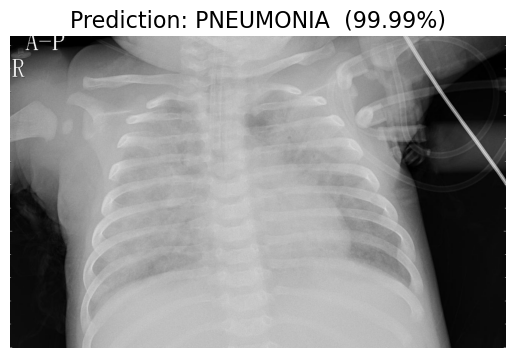

'PNEUMONIA'

In [59]:
predict_image("abnorm (1).jpeg") 

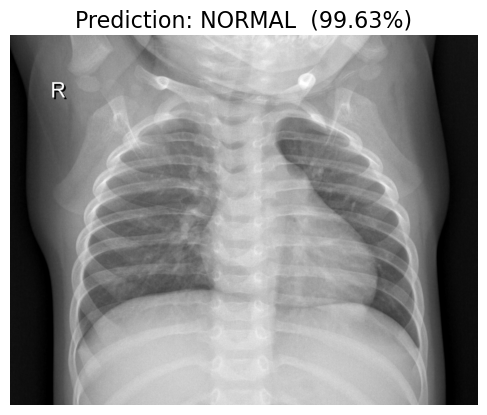

'NORMAL'

In [60]:
predict_image("norm (4).jpeg") 

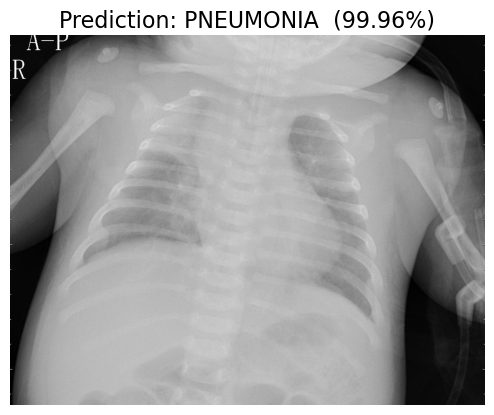

'PNEUMONIA'

In [61]:
predict_image("abnorm (2).jpeg")

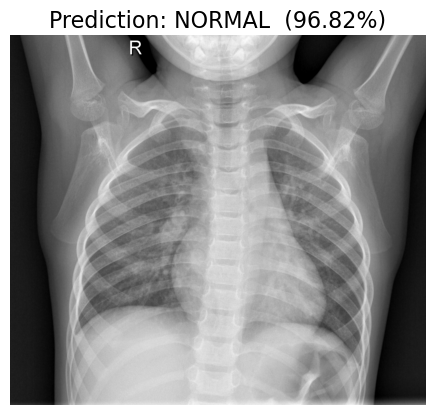

'NORMAL'

In [63]:
predict_image('norm (5).jpeg') 

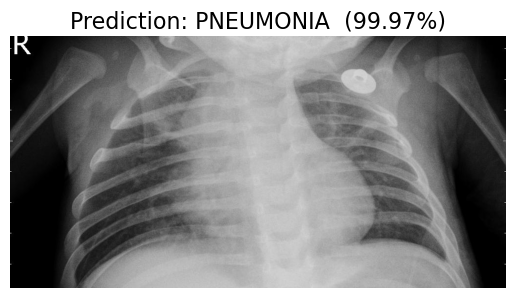

'PNEUMONIA'

In [66]:
predict_image("abnorm (3).jpeg") 

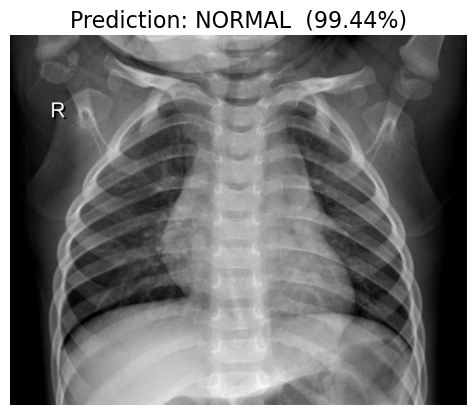

'NORMAL'

In [69]:
predict_image("norm (6).jpeg")

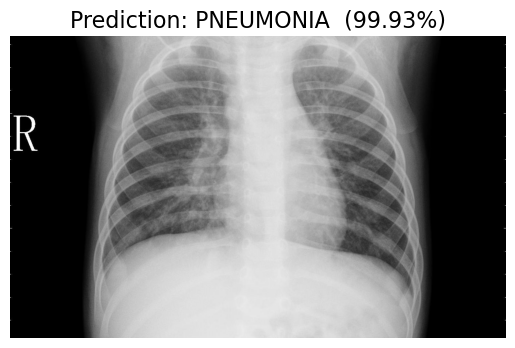

'PNEUMONIA'

In [71]:
predict_image("abnorm (4).jpeg")

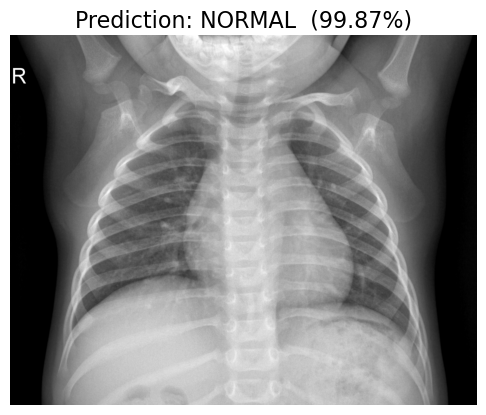

'NORMAL'

In [73]:
predict_image("norm (7).jpeg") 

```python
Here's the reason why we redefine the CNN architecture in the prediction file
When we save a model in PyTorch with torch.save(model.state_dict(), "model.pth"), PyTorch only saves the weights (numbers) — not the architecture (the blueprint/structure).


The architecture is the empty building (layers, connections, shapes).
The state_dict is the furniture inside (the learned weights).

model = CNN(num_classes=2)         # rebuild the empty architecture
model.load_state_dict(torch.load("model.pth"))  # load the saved weights into it
model.eval()                        # switch to prediction mode

```